In [1]:
import os
import sys
from dotenv import load_dotenv
load_dotenv() 

# Set the target folder name you want to reach
target_folder = "NCEAS_Unsupervised_NLP"
# Get the current working directory
current_dir = os.getcwd()

# Loop to move up the directory tree until we reach the target folder
while os.path.basename(current_dir) != target_folder:
    parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
    if parent_dir == current_dir:
        # If we reach the root directory and haven't found the target, exit
        raise FileNotFoundError(f"{target_folder} not found in the directory tree.")
    current_dir = parent_dir

# Change working directory to the project root
os.chdir(current_dir)

# Add the "NCEAS_Unsupervised_NLPt" directory to sys.path
sys.path.insert(0, current_dir)

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import seaborn as sns
import ipywidgets as widget
from itertools import cycle
import json
import itertools
from sklearn.metrics import adjusted_mutual_info_score

In [3]:
embedding_models = [
    "Qwen3-Embedding-0.6B",
    "all-MiniLM-L6-v2"
]

In [4]:
comparison = pd.read_csv("src/evaluations/arxiv/results/arxiv_comparison.csv")
hier = pd.read_csv("src/evaluations/arxiv/results/arxiv_hierarchical.csv")

# Make sure column names match
comparison = comparison.rename(columns={
    "reduction_method": "reduction",
    "cluster_method": "cluster"
})

hier = hier.rename(columns={
    "cluster_method": "cluster"
})

# Merge
df = pd.merge(
    comparison,
    hier,
    on=["embedding", "reduction", "cluster"],
    how="inner"
)

print(df.columns)

Index(['dataset_x', 'embedding', 'reduction', 'cluster', 'FM', 'Rand', 'ARI',
       'AMI', 'dataset_y', 'dendrogram_purity', 'lca_f1'],
      dtype='object')


In [5]:

params = [
    {'theme': None, 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': None, 'noise': None, 'branching': 'random'},
    {'theme': None, 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms': None, 'noise': None, 'branching': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': 10,'noise': None, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': 0,'noise': None, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms': 10,'noise': None, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms': 0,'noise': None, '': 'random'},
    # {'theme': "Energy, Ecosystems, and Humans", 't': 1.0, 'maxsub': 3, 'depth': 5,'synonyms':10,'noise':0.25,'':'random'},
    # # {'theme': "Energy, Ecosystems, and Humans", 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': None, '': 'random'},
    # {'theme': "Offshore energy impacts on fisheries", 't': 1.0, 'maxsub': 3, 'depth': 5,'synonyms':10,'noise':0.25,'':'random'},
    # # {'theme': "Offshore energy impacts on fisheries", 't': 1.0, 'maxsub': 5, 'depth': 3,'synonyms':10,'noise':0.25,'':'random'},
    # {'theme': "West Java, Indonesia", 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms':10,'noise':0.25,'':'random'},
    # # {'theme': "West Java, Indonesia", 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': None, '': 'random'},

    # # Additional entries with noise=0.25
    # {'theme': None, 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': None,'noise': 0.25, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms': None,'noise': 0.25, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': None,'noise': 0.0, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms': None,'noise': 0.0, '': 'random'},
    # {'theme':None,'t':1.0,'maxsub':3,'depth':5,'synonyms':10,'noise':0.25,'':'random'}
]


# params = [{'theme':None,'t':1.0,'maxsub':3,'depth':5,'synonyms':10,'noise':0.25,'':'random'}]

In [6]:
import os
print(os.getcwd())

/Users/sukainaalkhalidy/Desktop/CMSE 495 capstone/NCEAS_Unsupervised_NLP


In [7]:
import json

with open('src/evaluations/combo_color_map.json', 'r') as file:
    combo_color_map = json.load(file)

In [8]:
# ========================
# Load BOTH embeddings
# ========================
df_qwen = pd.read_csv("Qwen3-Embedding-0.6B_results/qwen3_arxiv_results.csv")
df_qwen["embedding"] = "Qwen"

df_minilm = pd.read_csv("all-MiniLM-L6-v2_results/all_MiniLM_other_arxiv_results.csv")
df_minilm["embedding"] = "MiniLM"

df = pd.concat([df_qwen, df_minilm], ignore_index=True)

print(df.head())

  reduction_method cluster_method  level        FM      Rand       ARI  \
0              PCA  Agglomerative      2  0.933393  0.911201  0.800560   
1              PCA  Agglomerative     62  0.213036  0.933818  0.157418   
2              PCA             DC      2  0.591714  0.506226 -0.016413   
3              PCA             DC     62  0.226867  0.917260  0.181618   
4              PCA        HDBSCAN      2  0.810250  0.656527 -0.000048   

  embedding  
0      Qwen  
1      Qwen  
2      Qwen  
3      Qwen  
4      Qwen  


In [9]:
import os

print(os.listdir("Qwen3-Embedding-0.6B_results"))

['qwen3_arxiv_results.csv']


### Note on Cluster Levels in the arXiv Evaluation

In the arXiv benchmark, the column called `level` does not represent hierarchical depth**.  
Instead, it represents the number of clusters used in the clustering evaluation**. For this dataset we evaluate clustering performance at two different resolutions:

2 clusters  → coarse grouping
62 clusters → fine-grained grouping

The plots therefore show how clustering performance changes when moving from a **coarse clustering structure (2 clusters)** to a **fine-grained clustering structure (62 clusters)**.


None - Diffusion Condensation
None - HDBSCAN
None - Agglomerative
UMAP - Diffusion Condensation
UMAP - HDBSCAN
UMAP - Agglomerative
PCA - Diffusion Condensation
PCA - HDBSCAN
PCA - Agglomerative
BASE-PHATE - Diffusion Condensation
BASE-PHATE - HDBSCAN
BASE-PHATE - Agglomerative
PHATE - Diffusion Condensation
PHATE - HDBSCAN
PHATE - Agglomerative


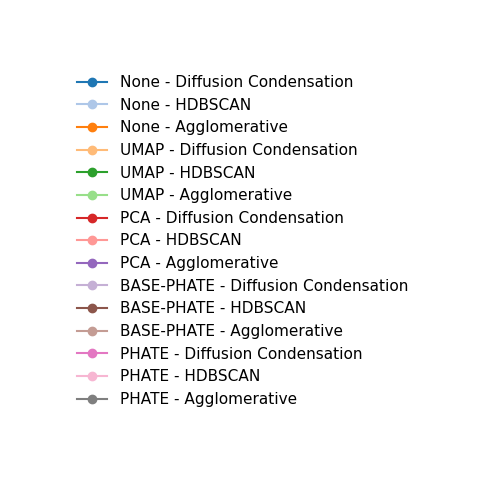

In [10]:
import os
import matplotlib.pyplot as plt

# Create a dummy figure just for the legend
fig, ax = plt.subplots(figsize=(6,6))

lines = []
labels = []

for combo_key, color in combo_color_map.items():

    method, cluster = combo_key.split("_", 1)
    label = f"{method} - {cluster}"

    print(label)

    line, = ax.plot([], [], marker='o', color=color, label=label)

    lines.append(line)
    labels.append(label)

# Create legend
legend = ax.legend(
    handles=lines,
    labels=labels,
    loc='center',
    frameon=False,
    fontsize=11
)

# Hide axes
ax.axis('off')

# Create folder
os.makedirs('legend_only_plots', exist_ok=True)

# Save legend image
legend_file = 'legend_only_plots/legend_methods.png'

fig.savefig(
    legend_file,
    dpi=300,
    bbox_inches='tight',
    transparent=True
)

plt.show()

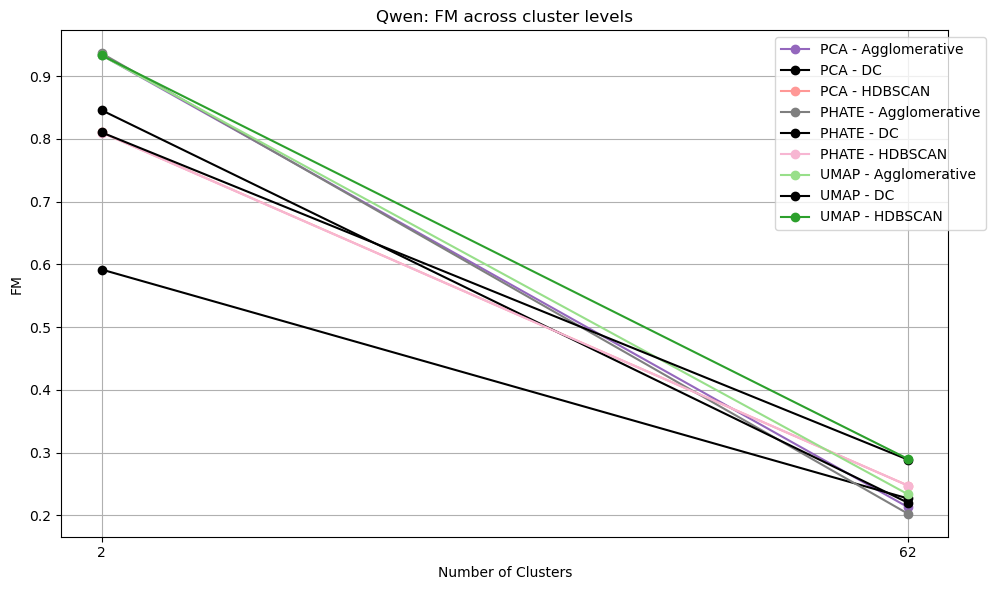

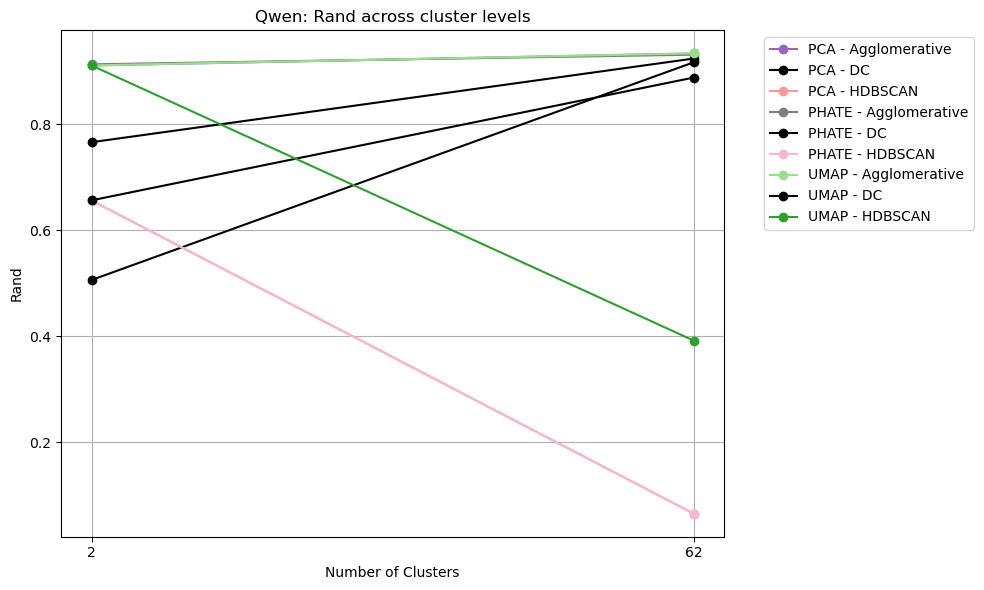

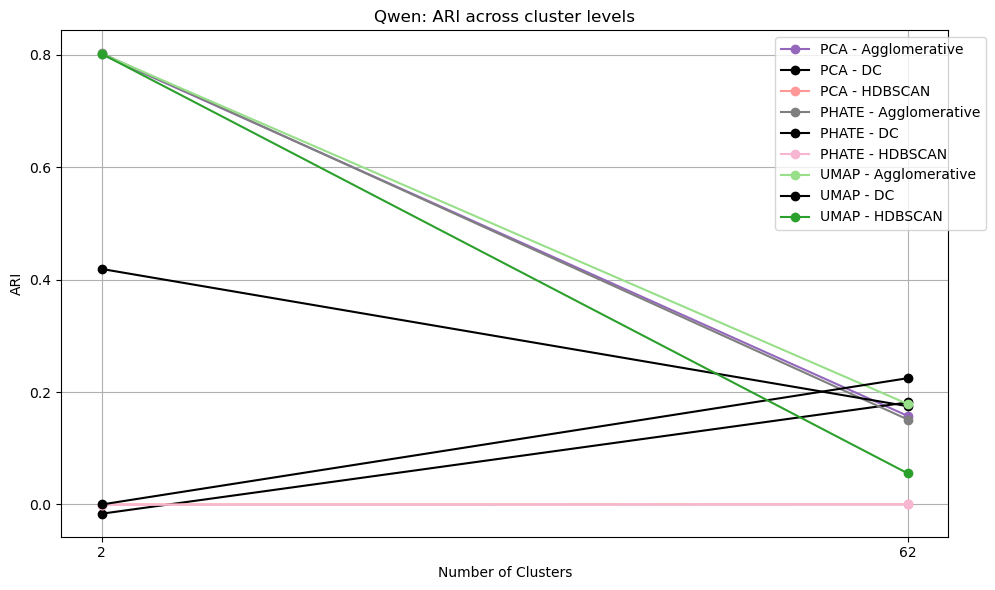

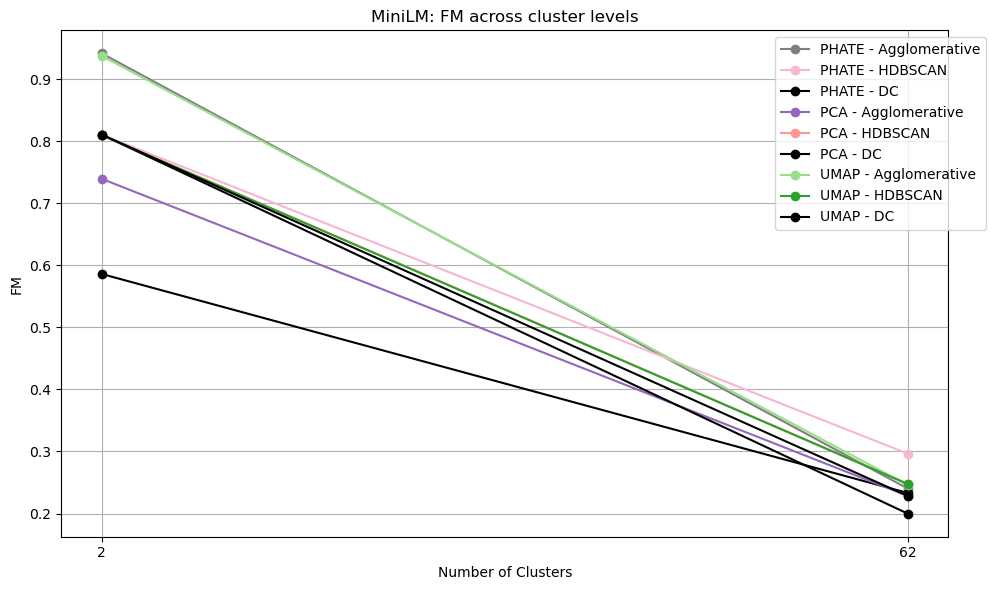

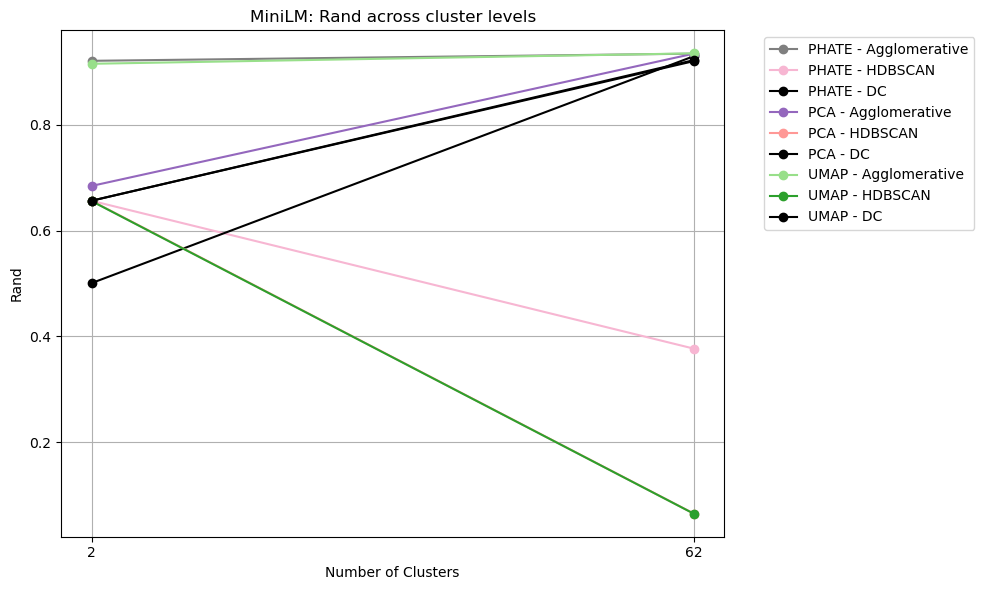

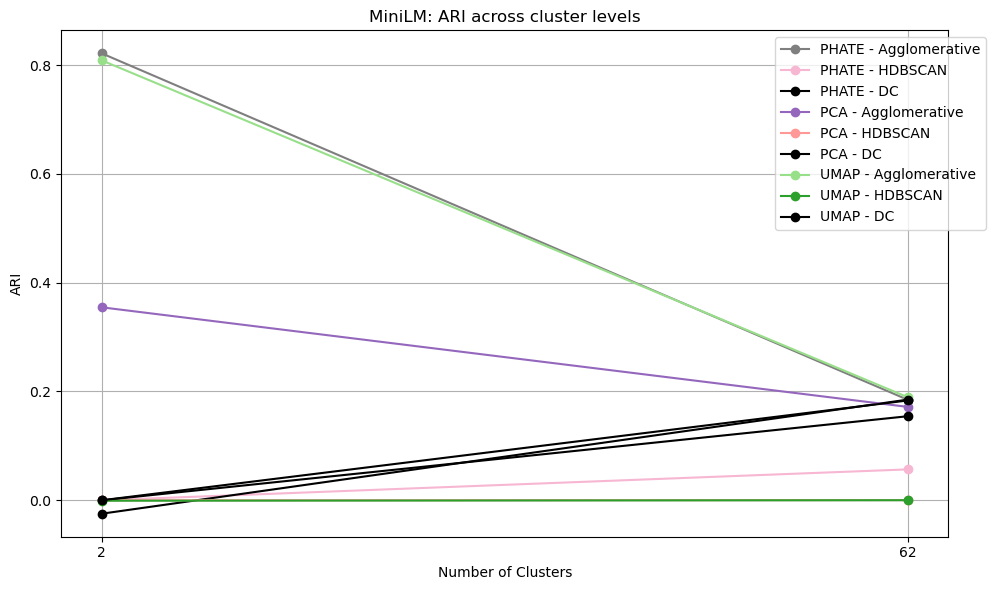

In [11]:
scores = ["FM", "Rand", "ARI"]
levels = sorted(df["level"].unique())

for emb in df["embedding"].unique():

    df_emb = df[df["embedding"] == emb]

    for score in scores:

        plt.figure(figsize=(10,6))

        for method in df_emb['reduction_method'].unique():
            for cluster in df_emb['cluster_method'].unique():

                subset = df_emb[
                    (df_emb['reduction_method'] == method) &
                    (df_emb['cluster_method'] == cluster)
                ]

                if subset.empty:
                    continue

                subset = subset.sort_values("level")

                combo_key = f"{method}_{cluster}"
                color = combo_color_map.get(combo_key, "black")

                plt.plot(
                    subset["level"],
                    subset[score],
                    marker="o",
                    label=f"{method} - {cluster}",
                    color=color
                )

        plt.title(f"{emb}: {score} across cluster levels")
        plt.xlabel("Number of Clusters")
        plt.ylabel(score)

        plt.xticks(levels)
        plt.grid(True)

        plt.legend(bbox_to_anchor=(1.05,1))
        plt.tight_layout()
        plt.show()

# Summary of Visualization Choice

In this analysis, boxplots were not used because the dataset does not contain multiple observations for each method and cluster resolution combination. Boxplots are typically used to visualize the distribution of values when there are many observations per group (for example, multiple runs, seeds, or trials). In this case, the results dataset contains only a single evaluation score for each combination of dimensionality reduction method, clustering algorithm, and cluster resolution.

The dataset has the following structure:

- **reduction_method:** dimensionality reduction technique (PCA, UMAP, PHATE)  
- **cluster_method:** clustering algorithm (Agglomerative, Diffusion Condensation, HDBSCAN)  
- **level:** number of clusters used in the evaluation (2 clusters and 62 clusters)  
- **evaluation metrics:** FM, Rand, and ARI scores  

Each method–cluster pair only has one score per cluster resolution, meaning there is no distribution of values to summarize with a boxplot. Because of this, a boxplot would collapse to a single line rather than showing quartiles, medians, and variability.

Instead, line plots were used to visualize how clustering performance changes across cluster resolutions. Line plots are more appropriate for this dataset because they clearly show the change in performance from coarse clustering (2 clusters) to more fine-grained clustering (62 clusters) for each method combination. This allows for direct comparison of how different dimensionality reduction and clustering techniques perform as the number of clusters increases.

Overall, this visualization approach better reflects the structure of the dataset and highlights the key trend in the results: clustering performance generally decreases as the number of clusters increases and the clustering task becomes more granular.